# London housing — Phase 1

Load → EDA → cleansing → **calendar-fair** train/val/test (70% / 10% / 20% of **time span** on `history_date`) → train-only preprocessing. Target: `history_price`. Phase 2 adds the regressor and metrics.

## Config

- **Primary data path:** `dataset/kaggle_london_house_price_data.csv` under the project root (found by walking up from the current working directory, so it still works when cwd is `.ipynb_checkpoints`). Prefer opening `notebooks/01_london_phase1.ipynb`, not the checkpoint copy.
- Set `USE_KAGGLEHUB = True` only if you want to download via Kaggle credentials instead.
- **Anaconda Jupyter:** red server log lines like `aext_core_server` / `missing refresh_token` / `nucleus_token` are optional cloud UI features failing without login—they do not break the notebook. To avoid them, run Jupyter with the same interpreter you used for `pip install` (e.g. `py -3 -m jupyter notebook`) or use VS Code / Cursor’s built-in notebook runner.

In [1]:
from pathlib import Path

USE_KAGGLEHUB = False
PRIMARY_DATE_COL = "history_date"
TARGET_COL = "history_price"
TRAIN_TIME_FRAC = 0.70
VAL_TIME_FRAC = 0.10
TEST_TIME_FRAC = 0.20
assert abs(TRAIN_TIME_FRAC + VAL_TIME_FRAC + TEST_TIME_FRAC - 1.0) < 1e-9

def _find_repo_root() -> Path:
    """Resolve project root even when cwd is `.ipynb_checkpoints` or repo root."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        candidate = p / "dataset" / "kaggle_london_house_price_data.csv"
        if candidate.is_file():
            return p
    raise FileNotFoundError(
        f"Could not find dataset/kaggle_london_house_price_data.csv starting from {here}"
    )


ROOT = _find_repo_root()
DEFAULT_CSV = ROOT / "dataset" / "kaggle_london_house_price_data.csv"

if USE_KAGGLEHUB:
    import kagglehub
    p = Path(kagglehub.dataset_download("jakewright/house-price-data"))
    matches = list(p.rglob("kaggle_london_house_price_data.csv"))
    DATA_PATH = matches[0] if matches else p / "kaggle_london_house_price_data.csv"
else:
    DATA_PATH = DEFAULT_CSV

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {DATA_PATH}")
print("DATA_PATH:", DATA_PATH)

DATA_PATH: C:\Projects\ML Model\dataset\kaggle_london_house_price_data.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

## Load

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
df.head()

(418201, 28)


,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,rentEstimate_lowerPrice,rentEstimate_currentPrice,rentEstimate_upperPrice,saleEstimate_lowerPrice,saleEstimate_currentPrice,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,NaN,2100.0,2350.0,2600.0,570000.0,600000.0,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,NaN,2100.0,2350.0,2600.0,540000.0,600000.0,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Leasehold,Flat/Maisonette,C,2650.0,2950.0,3250.0,683000.0,759000.0,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,1850.0,2000.0,2100.0,368000.0,388000.0,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,4350.0,4850.0,5350.0,1198000.0,1261000.0,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


## EDA — structure and missingness

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                418201 non-null  str    
 1   postcode                                   418201 non-null  str    
 2   country                                    418201 non-null  str    
 3   outcode                                    418201 non-null  str    
 4   latitude                                   418201 non-null  float64
 5   longitude                                  418201 non-null  float64
 6   bathrooms                                  340270 non-null  float64
 7   bedrooms                                   377665 non-null  float64
 8   floorAreaSqM                               392991 non-null  float64
 9   livingRooms                                357701 non-null  float64
 10  tenure             

In [5]:
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)
na_pct.head(20)

history_percentageChange                     43.093871
history_numericChange                        43.093871
currentEnergyRating                          20.211812
bathrooms                                    18.634819
livingRooms                                  14.466728
bedrooms                                      9.692947
floorAreaSqM                                  6.028202
tenure                                        2.752743
rentEstimate_lowerPrice                       0.416307
rentEstimate_currentPrice                     0.416307
rentEstimate_upperPrice                       0.416307
propertyType                                  0.271640
saleEstimate_confidenceLevel                  0.153036
saleEstimate_upperPrice                       0.153036
saleEstimate_ingestedAt                       0.153036
saleEstimate_valueChange.numericChange        0.153036
saleEstimate_valueChange.saleDate             0.153036
saleEstimate_valueChange.percentageChange     0.153036
saleEstima

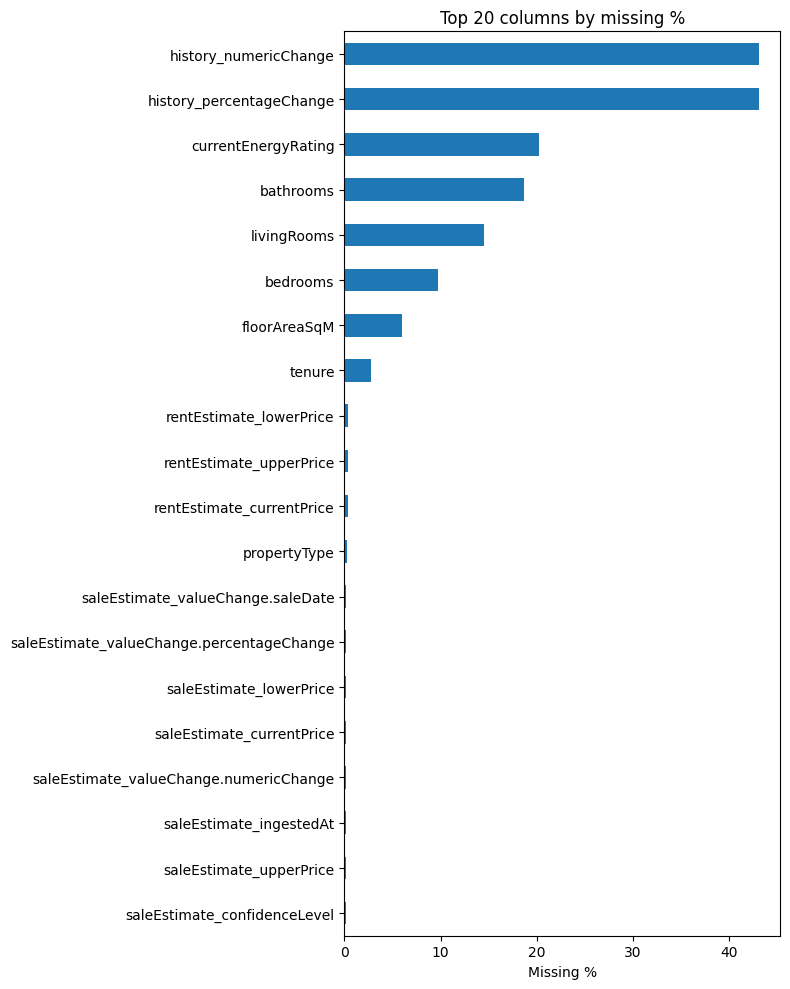

In [6]:
fig, ax = plt.subplots(figsize=(8, 10))
na_pct.head(20).sort_values().plot.barh(ax=ax)
ax.set_xlabel("Missing %")
ax.set_title("Top 20 columns by missing %")
plt.tight_layout()

## EDA — date columns and target coverage

In [7]:
date_cols = [
    "history_date",
    "saleEstimate_ingestedAt",
    "saleEstimate_valueChange.saleDate",
]
for c in date_cols:
    if c not in df.columns:
        continue
    s = pd.to_datetime(df[c], errors="coerce", utc=True)
    print(c, "non-null", s.notna().sum(), "unique", s.nunique(dropna=True), "min", s.min(), "max", s.max())

history_date non-null 418201 unique 8325 min 1995-01-02 00:00:00+00:00 max 2024-09-27 00:00:00+00:00
saleEstimate_ingestedAt non-null 417561 unique 4 min 2024-10-07 13:26:59.894000+00:00 max 2025-02-06 14:05:28.374000+00:00
saleEstimate_valueChange.saleDate non-null 417561 unique 6241 min 1995-01-06 00:00:00+00:00 max 2024-09-27 00:00:00+00:00


In [8]:
t_hist = pd.to_datetime(df[PRIMARY_DATE_COL], errors="coerce")
y = df[TARGET_COL]
both = t_hist.notna() & y.notna()
print("rows with date + target:", both.sum(), "of", len(df))

rows with date + target: 418201 of 418201


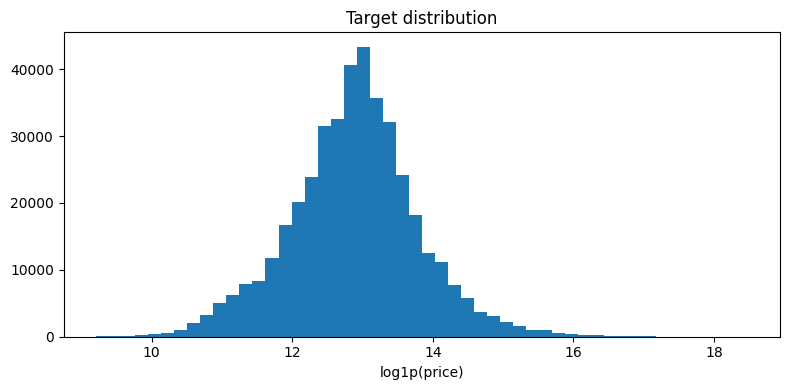

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(pd.to_numeric(df[TARGET_COL], errors="coerce").dropna()), bins=50)
ax.set_xlabel("log1p(price)")
ax.set_title("Target distribution")
plt.tight_layout()

## EDA — grain and duplicates

In [10]:
print("unique history_date:", df[PRIMARY_DATE_COL].nunique())
key = ["fullAddress", PRIMARY_DATE_COL, TARGET_COL]
dup = df.duplicated(subset=key, keep=False)
print("rows part of duplicate key (address+date+price):", dup.sum())

unique history_date: 8325
rows part of duplicate key (address+date+price): 204596


## Decision (Phase 1)

- **PRIMARY_DATE_COL:** `history_date` — full coverage with the target; spans 1995–2024; defines a clear time axis.
- **TARGET_COL:** `history_price` — aligned with observed history; exclude vendor `saleEstimate_*` / `rentEstimate_*` from **features** to avoid pipeline leakage (optional benchmark in Phase 2).
- **Split:** **Calendar fairness** — the train/val/test windows cover **70% / 10% / 20% of elapsed calendar time** between min and max `history_date`. Row counts will **not** match those percentages (recent years are denser).

On the full Kaggle-scale file this yields roughly ~49% / ~9% / ~42% of **rows**; every split still has large *N*.

## Cleansing

In [11]:
clean = df.copy()
clean[PRIMARY_DATE_COL] = pd.to_datetime(clean[PRIMARY_DATE_COL], errors="coerce")
clean = clean.dropna(subset=[PRIMARY_DATE_COL, TARGET_COL])
clean[TARGET_COL] = pd.to_numeric(clean[TARGET_COL], errors="coerce")
clean = clean.dropna(subset=[TARGET_COL])
for c in ["bathrooms", "bedrooms", "floorAreaSqM", "livingRooms", "latitude", "longitude"]:
    if c in clean.columns:
        clean[c] = pd.to_numeric(clean[c], errors="coerce")
clean["history_year"] = clean[PRIMARY_DATE_COL].dt.year.astype("Int64")
clean["history_month"] = clean[PRIMARY_DATE_COL].dt.month.astype("Int64")
print("after date/target filter:", clean.shape)

after date/target filter: (418201, 30)


## Calendar train / val / test split

Boundaries: `t_min + 0.7 * span` and `t_min + 0.8 * span`.

In [12]:
def calendar_split_masks(dates: pd.Series, train_f: float, val_f: float, test_f: float):
    assert abs(train_f + val_f + test_f - 1.0) < 1e-9
    t = pd.to_datetime(dates)
    t_min, t_max = t.min(), t.max()
    span_sec = (t_max - t_min).total_seconds()
    if span_sec <= 0:
        raise ValueError("Zero time span")
    cut_train_end = t_min + pd.Timedelta(seconds=train_f * span_sec)
    cut_val_end = t_min + pd.Timedelta(seconds=(train_f + val_f) * span_sec)
    train_m = t <= cut_train_end
    val_m = (t > cut_train_end) & (t <= cut_val_end)
    test_m = t > cut_val_end
    return train_m, val_m, test_m, cut_train_end, cut_val_end, t_min, t_max


train_m, val_m, test_m, cut1, cut2, t_min, t_max = calendar_split_masks(
    clean[PRIMARY_DATE_COL],
    TRAIN_TIME_FRAC,
    VAL_TIME_FRAC,
    TEST_TIME_FRAC,
)

train_df = clean.loc[train_m].copy()
val_df = clean.loc[val_m].copy()
test_df = clean.loc[test_m].copy()

print("t_min", t_min, "t_max", t_max)
print("cut train|val", cut1, "cut val|test", cut2)
print("rows train/val/test:", len(train_df), len(val_df), len(test_df))
print(
    "row %:",
    round(100 * len(train_df) / len(clean), 2),
    round(100 * len(val_df) / len(clean), 2),
    round(100 * len(test_df) / len(clean), 2),
)

t_min 1995-01-02 00:00:00 t_max 2024-09-27 00:00:00
cut train|val 2015-10-26 16:48:00 cut val|test 2018-10-16 19:11:59.999999872
rows train/val/test: 206274 36012 175915
row %: 49.32 8.61 42.06


In [13]:
def assert_temporal_purity(a: pd.DataFrame, b: pd.DataFrame, name_a: str, name_b: str):
    ta = a[PRIMARY_DATE_COL].max()
    tb = b[PRIMARY_DATE_COL].min()
    assert ta <= tb, f"{name_a} max {ta} > {name_b} min {tb}"


assert_temporal_purity(train_df, val_df, "train", "val")
assert_temporal_purity(val_df, test_df, "val", "test")
print("Temporal ordering OK: train ≤ val ≤ test on calendar.")

Temporal ordering OK: train ≤ val ≤ test on calendar.


## Features (v1) and train-only preprocessing

Numeric + low-cardinality categoricals. Vendor estimate and rent columns are **excluded**.

In [14]:
DROP_FROM_FEATURES = {
    TARGET_COL,
    PRIMARY_DATE_COL,
    "fullAddress",
    "postcode",
    "outcode",
    "country",
    "history_percentageChange",
    "history_numericChange",
}
for c in clean.columns:
    if c.startswith("saleEstimate_") or c.startswith("rentEstimate_"):
        DROP_FROM_FEATURES.add(c)

feature_cols = [c for c in clean.columns if c not in DROP_FROM_FEATURES]
numeric_features = [
    c
    for c in feature_cols
    if pd.api.types.is_numeric_dtype(clean[c]) or c in ("history_year", "history_month")
]
categorical_features = [c for c in feature_cols if c not in numeric_features]
print("numeric:", numeric_features)
print("categorical:", categorical_features)

numeric: ['latitude', 'longitude', 'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'history_year', 'history_month']
categorical: ['tenure', 'propertyType', 'currentEnergyRating']


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL].to_numpy()
X_val = val_df[feature_cols]
y_val = val_df[TARGET_COL].to_numpy()
X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL].to_numpy()

preprocess.fit(X_train)
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print("Transformed shapes:", X_train_t.shape, X_val_t.shape, X_test_t.shape)

Transformed shapes: (206274, 38) (36012, 38) (175915, 38)


## Optional: save cleaned table

Writes under `data/` (gitignored). Uncomment to run.

In [16]:
# out_dir = ROOT / "data"
# out_dir.mkdir(exist_ok=True)
# clean.to_parquet(out_dir / "london_clean.parquet", index=False)
# print("saved", out_dir / "london_clean.parquet")

## Next (Phase 2)

Fit a regressor on `X_train_t`, tune on `X_val_t`, report MAE/RMSE on `X_test_t`; optional naive and `saleEstimate_*` benchmarks.